# Vectors, Part 1

Notebook ini merangkum Chapter 2 dari buku **Practical Linear Algebra for Data Science** karya Mike X Cohen. Chapter ini membahas dasar-dasar vector sebagai fondasi utama linear algebra, mulai dari cara membuat vector di NumPy, memahami orientasi dan dimensionalitas, melakukan operasi aritmetika vector, hingga memahami dot product dan orthogonal vector decomposition.

Materi dalam notebook ini disusun dalam Bahasa Indonesia, dengan kode dan rumus yang mengikuti pembahasan chapter.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Menjelaskan pengertian vector sebagai ordered list of numbers.
- Membedakan dimensionality dan orientation pada vector.
- Membuat vector dalam bentuk list, NumPy array, row vector, dan column vector.
- Memahami perbedaan istilah dimensi dalam matematika dan Python.
- Melakukan operasi vector addition, subtraction, scalar multiplication, dan scalar addition.
- Memahami transpose dan broadcasting dalam NumPy.
- Menghitung magnitude atau norm sebuah vector.
- Membuat unit vector dari vector nonzero.
- Menghitung dan menafsirkan dot product.
- Memahami hubungan dot product dengan orthogonal vectors.
- Memahami Hadamard multiplication dan outer product.
- Menjelaskan konsep orthogonal vector decomposition.

## Persiapan Library

Chapter ini menggunakan `NumPy` untuk membuat dan menghitung operasi vector. `Matplotlib` digunakan hanya untuk visualisasi yang sesuai dengan konsep geometri vector pada chapter.

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2024)

## Ringkasan Chapter

Chapter ini memperkenalkan vector sebagai fondasi dari linear algebra. Vector dijelaskan sebagai daftar angka yang berurutan. Dalam konteks aplikasi dan data science, vector biasanya berisi angka real dan dapat digunakan untuk merepresentasikan data, arah, posisi, fitur, atau besaran tertentu.

Pembahasan awal berfokus pada dua karakter penting vector, yaitu dimensionality dan orientation. Dimensionality dalam matematika berarti jumlah elemen dalam vector, sedangkan orientation menjelaskan apakah vector berbentuk baris atau kolom. Chapter ini juga menekankan adanya perbedaan terminologi antara matematika dan Python. Dalam Python, bentuk array dilihat dari shape dan jumlah axis, sehingga vector matematika yang berdimensi banyak belum tentu disebut multidimensional array dalam NumPy.

Selanjutnya, chapter ini membahas operasi dasar vector, seperti addition, subtraction, scalar multiplication, scalar addition, transpose, dan broadcasting. Operasi-operasi tersebut terlihat sederhana, tetapi menjadi dasar bagi banyak operasi linear algebra lanjutan. Chapter ini juga menunjukkan bahwa orientasi vector dapat memengaruhi hasil operasi di Python, terutama karena adanya broadcasting.

Bagian berikutnya membahas magnitude atau norm vector, yaitu panjang geometris dari vector. Dari konsep norm, chapter ini memperkenalkan unit vector, yaitu vector dengan magnitude sama dengan satu. Unit vector penting dalam banyak topik lanjutan seperti orthogonal matrices, rotation matrices, eigenvectors, dan singular vectors.

Dot product menjadi salah satu pembahasan utama dalam chapter ini. Dot product dihitung dengan mengalikan elemen-elemen yang bersesuaian dari dua vector, kemudian menjumlahkan hasilnya. Dot product menghasilkan satu nilai skalar yang dapat ditafsirkan sebagai ukuran hubungan atau similarity antara dua vector. Secara geometri, dot product juga berkaitan dengan sudut antara dua vector. Hal penting yang ditekankan adalah bahwa vector orthogonal memiliki dot product sama dengan nol.

Chapter ini juga memperkenalkan beberapa bentuk perkalian vector lainnya, yaitu Hadamard multiplication dan outer product. Hadamard multiplication adalah perkalian elemen demi elemen, sedangkan outer product menghasilkan matrix dari dua vector. Di akhir chapter, pembahasan masuk ke orthogonal vector decomposition, yaitu proses memecah vector menjadi dua komponen: satu komponen parallel terhadap reference vector dan satu komponen perpendicular terhadap reference vector.

Secara keseluruhan, chapter ini membangun dasar penting untuk memahami topik-topik berikutnya dalam buku, seperti vector spaces, matrix operations, QR decomposition, least squares, eigendecomposition, dan SVD.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Creating and Visualizing Vectors in NumPy | Membuat vector sebagai list, array, row vector, dan column vector. |
| Geometry of Vectors | Vector dapat dipahami sebagai garis berarah dengan magnitude dan direction. |
| Operations on Vectors | Operasi dasar seperti addition, subtraction, scalar multiplication, transpose, dan broadcasting. |
| Vector Magnitude and Unit Vectors | Menghitung norm vector dan membuat vector dengan magnitude satu. |
| The Vector Dot Product | Menghitung dot product dan memahami maknanya sebagai scalar relationship. |
| Other Vector Multiplications | Hadamard multiplication dan outer product. |
| Orthogonal Vector Decomposition | Memecah vector menjadi komponen parallel dan perpendicular terhadap reference vector. |

## Creating and Visualizing Vectors in NumPy

Dalam linear algebra, vector adalah daftar angka yang berurutan. Chapter ini menekankan bahwa vector memiliki dua karakteristik awal yang penting:

- **Dimensionality**, yaitu jumlah angka atau elemen dalam vector.
- **Orientation**, yaitu apakah vector berbentuk column vector atau row vector.

Dalam notasi matematika, vector dengan dua elemen dapat disebut sebagai anggota dari $\mathbb{R}^2$, sedangkan vector dengan empat elemen dapat disebut sebagai anggota dari $\mathbb{R}^4$.

Namun, dalam Python dan NumPy, istilah dimensi bisa sedikit berbeda. Sebuah NumPy array seperti `[1, 2, 3]` dianggap sebagai 1D array, meskipun secara matematika vector tersebut memiliki tiga elemen.

## Contoh Column Vector dan Row Vector

Contoh vector yang dibahas pada chapter:

$$
x =
\begin{bmatrix}
1 \\
4 \\
5 \\
6
\end{bmatrix}
,\quad
y =
\begin{bmatrix}
.3 \\
-7
\end{bmatrix}
,\quad
z =
\begin{bmatrix}
1 & 4 & 5 & 6
\end{bmatrix}
$$

Keterangan:

- $x$ = vector 4 dimensi dengan orientasi kolom.
- $y$ = vector 2 dimensi dengan orientasi kolom.
- $z$ = vector 4 dimensi dengan orientasi baris.
- $x$ dan $z$ memiliki elemen yang sama, tetapi secara teknis berbeda karena orientasinya berbeda.

## Membuat Vector di Python

Chapter ini menunjukkan empat cara membuat vector di Python:

- Python list
- NumPy 1D array
- NumPy row vector
- NumPy column vector

Perbedaan utamanya terlihat pada shape.

In [30]:
asList = [1, 2, 3]
asArray = np.array([1, 2, 3])           # 1D array
rowVec = np.array([[1, 2, 3]])          # row vector
colVec = np.array([[1], [2], [3]])      # column vector

print(f"asList : {np.shape(asList)}")
print(f"asArray: {asArray.shape}")
print(f"rowVec : {rowVec.shape}")
print(f"colVec : {colVec.shape}")

asList : (3,)
asArray: (3,)
rowVec : (1, 3)
colVec : (3, 1)


## Analisis Shape Vector

Output shape memperlihatkan bahwa:

| Object | Shape | Penjelasan |
|---|---|---|
| `asList` | `(3,)` | Python list berisi tiga elemen. |
| `asArray` | `(3,)` | NumPy 1D array tanpa orientasi row/column yang eksplisit. |
| `rowVec` | `(1, 3)` | Vector dengan 1 baris dan 3 kolom. |
| `colVec` | `(3, 1)` | Vector dengan 3 baris dan 1 kolom. |

Chapter ini menekankan bahwa orientasi vector kadang tidak penting ketika hanya menyimpan data, tetapi bisa menjadi penting ketika melakukan operasi linear algebra tertentu.

## Geometry of Vectors

Secara aljabar, vector adalah daftar angka berurutan. Secara geometri, vector dapat dipahami sebagai garis lurus yang memiliki panjang dan arah tertentu.

Vector memiliki dua titik penting:

- **Tail**, yaitu titik awal vector.
- **Head**, yaitu titik akhir vector.

Jika tail vector berada di origin, maka vector tersebut disebut berada dalam **standard position**. Dalam posisi ini, head vector sesuai dengan koordinat geometrisnya.

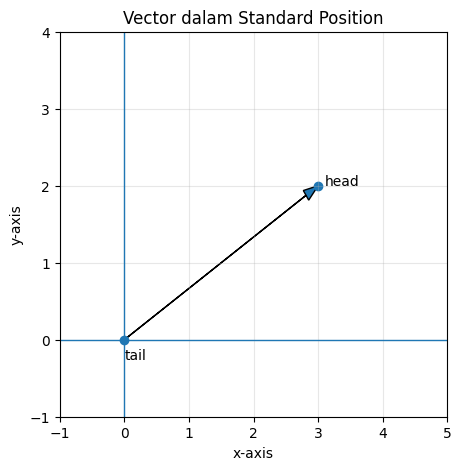

In [31]:
v = np.array([3, 2])

plt.figure(figsize=(5, 5))
plt.arrow(0, 0, v[0], v[1], head_width=0.15, length_includes_head=True)
plt.scatter([0, v[0]], [0, v[1]])
plt.text(0, -0.25, "tail")
plt.text(v[0] + 0.1, v[1], "head")
plt.xlim(-1, 5)
plt.ylim(-1, 4)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.title("Vector dalam Standard Position")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

## Operations on Vectors

Chapter ini menjelaskan bahwa vector dapat dianggap seperti “nouns” dalam cerita linear algebra, sedangkan operasi adalah “verbs” yang memberi aksi pada vector.

Operasi awal yang dibahas adalah:

- Vector addition
- Vector subtraction
- Vector-scalar multiplication
- Scalar-vector addition
- Transpose
- Broadcasting

## Adding Two Vectors

Vector addition dilakukan dengan menjumlahkan elemen-elemen yang posisinya sama.

Contoh:

$$
\begin{bmatrix}
4 \\
5 \\
6
\end{bmatrix}
+
\begin{bmatrix}
10 \\
20 \\
30
\end{bmatrix}
=
\begin{bmatrix}
14 \\
25 \\
36
\end{bmatrix}
$$

Keterangan:

- Vector pertama dan vector kedua harus memiliki dimensionality yang sama.
- Penjumlahan dilakukan element-wise.
- Vector di $\mathbb{R}^3$ tidak dapat dijumlahkan langsung dengan vector di $\mathbb{R}^5$.

In [32]:
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])

vPlusW = v + w

print(vPlusW)

[14 25 36]


## Subtracting Two Vectors

Vector subtraction juga dilakukan secara element-wise.

Contoh:

$$
\begin{bmatrix}
4 \\
5 \\
6
\end{bmatrix}
-
\begin{bmatrix}
10 \\
20 \\
30
\end{bmatrix}
=
\begin{bmatrix}
-6 \\
-15 \\
-24
\end{bmatrix}
$$

Keterangan:

- Elemen pertama dikurangi elemen pertama.
- Elemen kedua dikurangi elemen kedua.
- Proses ini berlaku hanya jika kedua vector memiliki dimensionality yang sama.

In [33]:
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])

vMinusW = v - w

print(vMinusW)

[ -6 -15 -24]


## Vector Addition dengan Dimensi Berbeda

Chapter ini menunjukkan bahwa vector dengan jumlah elemen berbeda tidak dapat dijumlahkan secara langsung.

In [34]:
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])
u = np.array([0, 3, 6, 9])

print("v + w =", v + w)

try:
    print(u + w)
except ValueError as e:
    print("Error:", e)

v + w = [14 25 36]
Error: operands could not be broadcast together with shapes (4,) (3,) 


## Orientasi Vector dan Broadcasting

Chapter ini juga menunjukkan bahwa orientasi dapat memengaruhi hasil operasi. Jika row vector dijumlahkan dengan column vector, NumPy tidak menghasilkan vector biasa, melainkan melakukan broadcasting.

In [35]:
v = np.array([[4, 5, 6]])        # row vector
w = np.array([[10, 20, 30]]).T   # column vector

v + w

array([[14, 15, 16],
       [24, 25, 26],
       [34, 35, 36]])

## Analisis Broadcasting pada Penjumlahan Vector

Hasil operasi di atas bukan vector dengan tiga elemen, melainkan matrix 3 × 3. Ini terjadi karena NumPy melakukan **broadcasting**, yaitu memperluas bentuk array agar operasi dapat dilakukan.

Dari contoh ini, chapter menekankan bahwa dua vector dapat dijumlahkan secara linear algebra hanya jika memiliki:

- dimensionality yang sama,
- orientasi yang sesuai.

Jika orientasinya berbeda, Python dapat memberikan hasil yang secara linear algebra mungkin tidak sesuai dengan ekspektasi.

## Geometry of Vector Addition and Subtraction

Secara geometri, vector addition dapat dipahami dengan menempatkan tail vector kedua pada head vector pertama. Vector hasil penjumlahan adalah vector dari tail pertama menuju head terakhir.

Untuk subtraction, dua vector diletakkan dengan tail yang sama. Vector selisih adalah garis dari head vector yang dikurangkan menuju head vector positif.

Chapter ini juga menekankan bahwa geometri vector subtraction penting karena menjadi dasar untuk orthogonal vector decomposition dan least squares.

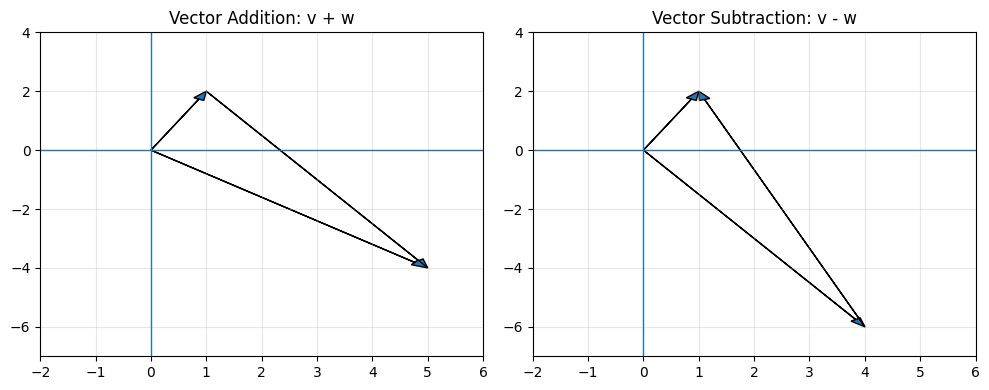

In [36]:
v = np.array([1, 2])
w = np.array([4, -6])

vPlusW = v + w
vMinusW = v - w

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Addition
axes[0].arrow(0, 0, v[0], v[1], head_width=0.2, length_includes_head=True, label="v")
axes[0].arrow(v[0], v[1], w[0], w[1], head_width=0.2, length_includes_head=True, label="w")
axes[0].arrow(0, 0, vPlusW[0], vPlusW[1], head_width=0.2, length_includes_head=True)
axes[0].set_title("Vector Addition: v + w")

# Subtraction
axes[1].arrow(0, 0, v[0], v[1], head_width=0.2, length_includes_head=True)
axes[1].arrow(0, 0, w[0], w[1], head_width=0.2, length_includes_head=True)
axes[1].arrow(w[0], w[1], vMinusW[0], vMinusW[1], head_width=0.2, length_includes_head=True)
axes[1].set_title("Vector Subtraction: v - w")

for ax in axes:
    ax.set_xlim(-2, 6)
    ax.set_ylim(-7, 4)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Vector-Scalar Multiplication

Scalar adalah angka tunggal yang tidak berada di dalam vector atau matrix. Vector-scalar multiplication dilakukan dengan mengalikan setiap elemen vector dengan scalar.

Contoh:

$$
\lambda = 4,\quad
w =
\begin{bmatrix}
9 \\
4 \\
1
\end{bmatrix}
,\quad
\lambda w =
\begin{bmatrix}
36 \\
16 \\
4
\end{bmatrix}
$$

Keterangan:

- $\lambda$ = scalar
- $w$ = vector
- $\lambda w$ = vector hasil perkalian scalar dengan setiap elemen $w$

In [37]:
lam = 4
w = np.array([9, 4, 1])

lam * w

array([36, 16,  4])

## The Zeros Vector

Chapter ini memperkenalkan **zeros vector**, yaitu vector yang seluruh elemennya bernilai nol. Zeros vector sering dilambangkan dengan $\mathbf{0}$.

Zeros vector penting karena dalam banyak masalah linear algebra, solusi nol sering disebut **trivial solution**. Banyak persoalan linear algebra mencari solusi nonzero atau nontrivial karena solusi nol sering tidak memberikan informasi yang berguna.

In [38]:
zero_vector = np.zeros(5)

zero_vector

array([0., 0., 0., 0., 0.])

## Perbedaan List dan NumPy Array pada Scalar Multiplication

Chapter ini menunjukkan bahwa tipe data sangat penting. Jika vector disimpan sebagai Python list, operasi `*` dengan integer akan mengulang list. Jika vector disimpan sebagai NumPy array, operasi `*` akan menjadi element-wise multiplication.

In [39]:
s = 2
a = [3, 4, 5]        # list
b = np.array(a)      # NumPy array

print("List * scalar:")
print(a * s)

print("\nNumPy array * scalar:")
print(b * s)

List * scalar:
[3, 4, 5, 3, 4, 5]

NumPy array * scalar:
[ 6  8 10]


## Scalar-Vector Addition

Dalam linear algebra formal, penjumlahan scalar dengan vector tidak didefinisikan karena keduanya adalah objek matematika yang berbeda. Namun, NumPy mengizinkan operasi ini dengan menambahkan scalar ke setiap elemen vector.

In [40]:
s = 2
v = np.array([3, 6])

s + v

array([5, 8])

## Geometri Vector-Scalar Multiplication

Scalar disebut scalar karena dapat mengubah skala vector.

Efek scalar terhadap vector:

| Nilai Scalar | Efek Geometris |
|---|---|
| $\sigma > 1$ | Vector menjadi lebih panjang. |
| $0 < \sigma < 1$ | Vector menjadi lebih pendek. |
| $\sigma = 0$ | Vector menjadi zeros vector. |
| $\sigma < 0$ | Vector berbalik arah sepanjang garis yang sama. |

Chapter ini menjelaskan bahwa scalar negatif dapat dianggap membalik vector 180°, tetapi vector tersebut masih berada pada garis yang sama.

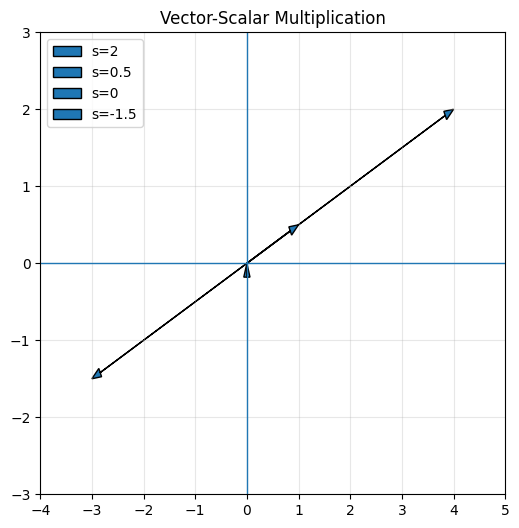

In [41]:
v = np.array([2, 1])
scalars = [2, 0.5, 0, -1.5]

plt.figure(figsize=(6, 6))

for s in scalars:
    sv = s * v
    plt.arrow(0, 0, sv[0], sv[1], head_width=0.12, length_includes_head=True, label=f"s={s}")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlim(-4, 5)
plt.ylim(-3, 3)
plt.grid(alpha=0.3)
plt.title("Vector-Scalar Multiplication")
plt.legend()
plt.show()

## Vector Averaging

Chapter ini menjelaskan bahwa vector-scalar multiplication dan vector addition dapat digunakan untuk menghitung rata-rata vector.

Untuk dua vector:

$$
\text{average} = \frac{1}{2}(v+w)
$$

Untuk $N$ vector:

$$
\text{average} = \frac{1}{N}\sum_{i=1}^{N}v_i
$$

Keterangan:

- $v_i$ = vector ke-$i$
- $N$ = jumlah vector

In [42]:
v = np.array([2, 4, 6])
w = np.array([10, 20, 30])

average_vector = 0.5 * (v + w)

average_vector

array([ 6., 12., 18.])

## Transpose

Transpose adalah operasi yang mengubah column vector menjadi row vector, atau sebaliknya. Secara umum, transpose menukar indeks baris dan kolom.

### Rumus Transpose

$$
m_{i,j}^{T} = m_{j,i}
$$

Keterangan:

- $m_{i,j}$ = elemen pada baris ke-$i$ dan kolom ke-$j$
- $m_{j,i}$ = elemen setelah posisi baris dan kolom ditukar
- $T$ = simbol transpose

Aturan penting:

$$
v^{TT} = v
$$

Artinya, jika vector ditranspose dua kali, orientasinya kembali seperti semula.

In [43]:
v = np.array([[1], [2], [3]])

print("Column vector:")
print(v)

print("\nTransposed vector:")
print(v.T)

print("\nTransposed twice:")
print(v.T.T)

Column vector:
[[1]
 [2]
 [3]]

Transposed vector:
[[1 2 3]]

Transposed twice:
[[1]
 [2]
 [3]]


## Vector Broadcasting in Python

Broadcasting adalah operasi NumPy yang memungkinkan operasi dilakukan antara array dengan shape berbeda, selama bentuknya kompatibel.

Chapter ini menunjukkan contoh column vector ditambah row vector.

In [44]:
v = np.array([[1, 2, 3]]).T    # column vector
w = np.array([[10, 20]])       # row vector

v + w

array([[11, 21],
       [12, 22],
       [13, 23]])

## Analisis Broadcasting

Pada contoh di atas:

$$
v =
\begin{bmatrix}
1 \\
2 \\
3
\end{bmatrix}
,\quad
w =
\begin{bmatrix}
10 & 20
\end{bmatrix}
$$

NumPy menghasilkan:

$$
\begin{bmatrix}
11 & 21 \\
12 & 22 \\
13 & 23
\end{bmatrix}
$$

Broadcasting bukan operasi klasik yang biasanya muncul di textbook linear algebra tradisional. Namun, broadcasting sering digunakan dalam numerical coding karena membuat operasi menjadi ringkas dan efisien.

## Vector Magnitude and Unit Vectors

Magnitude vector, atau norm, adalah panjang geometris vector dari tail ke head. Chapter ini menggunakan norma Euclidean.

### Rumus Norm Vector

$$
\|v\| = \sqrt{\sum_{i=1}^{n} v_i^2}
$$

Keterangan:

- $v$ = vector
- $v_i$ = elemen ke-$i$ dari vector
- $n$ = jumlah elemen vector
- $\|v\|$ = magnitude atau norm vector

Dalam Python, jumlah elemen vector dapat dicek dengan `len()`, sedangkan magnitude vector dihitung dengan `np.linalg.norm()`.

In [45]:
v = np.array([1, 2, 3, 7, 8, 9])

v_dim = len(v)
v_mag = np.linalg.norm(v)

print("Dimensionality:", v_dim)
print("Magnitude:", v_mag)

Dimensionality: 6
Magnitude: 14.422205101855956


## Unit Vectors

Unit vector adalah vector yang memiliki magnitude sama dengan satu.

### Rumus Unit Vector

$$
\hat{v} = \frac{1}{\|v\|}v
$$

Keterangan:

- $\hat{v}$ = unit vector yang searah dengan $v$
- $v$ = vector asal
- $\|v\|$ = magnitude vector $v$

Unit vector memiliki arah yang sama dengan vector asal, tetapi panjangnya dinormalisasi menjadi satu.

In [46]:
v = np.array([3, 4])

v_unit = (1 / np.linalg.norm(v)) * v

print("Original vector:", v)
print("Unit vector:", v_unit)
print("Norm of unit vector:", np.linalg.norm(v_unit))

Original vector: [3 4]
Unit vector: [0.6 0.8]
Norm of unit vector: 1.0


## Catatan tentang Zeros Vector dan Unit Vector

Chapter ini menekankan bahwa zeros vector tidak memiliki associated unit vector. Penyebabnya:

- zeros vector memiliki magnitude 0,
- tidak memiliki arah tertentu,
- tidak mungkin diskalakan menjadi vector dengan panjang nonzero.

Secara komputasi, membagi zeros vector dengan norm-nya akan menyebabkan pembagian dengan nol.

In [47]:
zero_v = np.array([0, 0])

try:
    zero_unit = zero_v / np.linalg.norm(zero_v)
    print(zero_unit)
except Exception as e:
    print("Error:", e)

[nan nan]


## The Vector Dot Product

Dot product adalah salah satu operasi terpenting dalam linear algebra. Dot product juga disebut inner product.

Dot product menghasilkan satu angka skalar. Angka ini memberikan informasi tentang hubungan antara dua vector.

### Rumus Dot Product

$$
\delta = \sum_{i=1}^{n} a_i b_i
$$

Keterangan:

- $\delta$ = hasil dot product
- $a$ = vector pertama
- $b$ = vector kedua
- $a_i$ = elemen ke-$i$ dari vector $a$
- $b_i$ = elemen ke-$i$ dari vector $b$
- $n$ = jumlah elemen vector

Dot product hanya valid untuk dua vector dengan dimensionality yang sama.

## Contoh Perhitungan Dot Product

Contoh dari chapter:

$$
\begin{bmatrix}
1 & 2 & 3 & 4
\end{bmatrix}
\cdot
\begin{bmatrix}
5 & 6 & 7 & 8
\end{bmatrix}
=
1 \times 5 + 2 \times 6 + 3 \times 7 + 4 \times 8
$$

$$
= 5 + 12 + 21 + 32
= 70
$$

In [48]:
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

np.dot(v, w)

np.int64(70)

## Dot Product dan Scalar Multiplication

Chapter ini menunjukkan bahwa jika salah satu vector dikalikan scalar, maka hasil dot product ikut diskalakan dengan nilai scalar tersebut.

Jika:

$$
v^T w = 70
$$

maka:

$$
(\sigma v)^T w = \sigma(v^T w)
$$

Keterangan:

- $\sigma$ = scalar
- $v$ dan $w$ = vector

In [49]:
s = 10
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

print("v dot w:", np.dot(v, w))
print("s*v dot w:", np.dot(s*v, w))

v dot w: 70
s*v dot w: 700


## Interpretasi Dot Product

Chapter ini menjelaskan dot product sebagai ukuran hubungan atau similarity antara dua vector. Jika dua vector berisi data yang berkaitan, dot product dapat bernilai besar. Namun, magnitude dot product dipengaruhi oleh skala data.

Contohnya, data tinggi dan berat badan dalam satuan gram dan sentimeter dapat menghasilkan dot product yang berbeda dari data dalam satuan pound dan feet. Karena itu, untuk analisis data, dot product sering perlu dinormalisasi. Chapter ini menyebut bahwa normalized dot product berhubungan dengan Pearson correlation coefficient, yang dibahas lebih lanjut di Chapter 4.

## The Dot Product Is Distributive

Dot product memiliki sifat distributif.

### Rumus Distributive Property pada Dot Product

$$
a^T(b+c) = a^Tb + a^Tc
$$

Keterangan:

- $a$, $b$, dan $c$ = vector dengan dimensionality yang sesuai
- $a^T(b+c)$ = dot product antara $a$ dan hasil penjumlahan $b+c$
- $a^Tb + a^Tc$ = jumlah dot product antara $a$ dengan masing-masing vector

Artinya, dot product terhadap hasil penjumlahan vector sama dengan jumlah dot product terhadap masing-masing vector.

In [50]:
a = np.array([0, 1, 2])
b = np.array([3, 5, 8])
c = np.array([13, 21, 34])

res1 = np.dot(a, b + c)
res2 = np.dot(a, b) + np.dot(a, c)

print("res1:", res1)
print("res2:", res2)

res1: 110
res2: 110


## Geometry of the Dot Product

Selain formula aljabar, dot product juga memiliki definisi geometris.

### Rumus Geometris Dot Product

$$
\alpha = \cos(\theta_{v,w})\|v\|\|w\|
$$

Keterangan:

- $\alpha$ = hasil dot product
- $\theta_{v,w}$ = sudut antara vector $v$ dan $w$
- $\|v\|$ = magnitude vector $v$
- $\|w\|$ = magnitude vector $w$

Rumus ini menunjukkan bahwa tanda dot product ditentukan oleh hubungan sudut antara dua vector.

## Interpretasi Tanda Dot Product

| Hubungan Geometris | Sudut | Nilai Cosine | Tanda Dot Product |
|---|---|---|---|
| Acute | $\theta < 90^\circ$ | positif | positif |
| Orthogonal | $\theta = 90^\circ$ | 0 | 0 |
| Obtuse | $\theta > 90^\circ$ | negatif | negatif |
| Collinear searah | $\theta = 0^\circ$ | 1 | maksimum positif |
| Collinear berlawanan arah | $\theta = 180^\circ$ | -1 | maksimum negatif |

Hal yang perlu diingat dari chapter ini:

**Orthogonal vectors have a zero dot product.**

Pernyataan tersebut berlaku dua arah:
- Jika dua vector orthogonal, dot product-nya nol.
- Jika dot product dua vector nol, maka keduanya orthogonal.

In [51]:
v = np.array([1, 0])
w = np.array([0, 1])

print("Dot product:", np.dot(v, w))

Dot product: 0


## Other Vector Multiplications

Selain dot product, chapter ini memperkenalkan beberapa bentuk perkalian vector lainnya:

- Hadamard multiplication
- Outer product
- Cross product dan triple product

Namun, cross product dan triple product hanya disebut secara singkat karena tidak banyak digunakan dalam aplikasi tech-related yang menjadi fokus buku.

## Hadamard Multiplication

Hadamard multiplication adalah perkalian element-wise antara dua vector.

Contoh:

$$
\begin{bmatrix}
5 \\
4 \\
8 \\
2
\end{bmatrix}
\odot
\begin{bmatrix}
1 \\
0 \\
.5 \\
-1
\end{bmatrix}
=
\begin{bmatrix}
5 \\
0 \\
4 \\
-2
\end{bmatrix}
$$

Keterangan:

- $\odot$ = simbol Hadamard multiplication
- Kedua vector harus memiliki dimensionality yang sama.
- Hasilnya adalah vector dengan dimensionality yang sama.

In [52]:
a = np.array([5, 4, 8, 2])
b = np.array([1, 0, .5, -1])

a * b

array([ 5.,  0.,  4., -2.])

## Error pada Hadamard Multiplication

Chapter ini memberi contoh bug ketika dua vector memiliki jumlah elemen berbeda. Hadamard multiplication hanya dapat dilakukan jika dimensionality sama.

In [53]:
a = np.array([5, 4, 8, 2])
b = np.array([1, 0, .5])

try:
    print(a * b)
except ValueError as e:
    print("Error:", e)

Error: operands could not be broadcast together with shapes (4,) (3,) 


## Outer Product

Outer product adalah cara membuat matrix dari column vector dan row vector. Berbeda dari dot product yang menghasilkan scalar, outer product menghasilkan matrix.

### Bentuk Outer Product

$$
\begin{bmatrix}
a \\
b \\
c
\end{bmatrix}
\begin{bmatrix}
d & e
\end{bmatrix}
=
\begin{bmatrix}
ad & ae \\
bd & be \\
cd & ce
\end{bmatrix}
$$

Keterangan:

- Vector pertama dipandang sebagai column vector.
- Vector kedua dipandang sebagai row vector.
- Hasil outer product adalah matrix.
- Dua vector dalam outer product boleh memiliki dimensionality berbeda.

In [54]:
a = np.array([1, 2, 3])
b = np.array([4, 5])

np.outer(a, b)

array([[ 4,  5],
       [ 8, 10],
       [12, 15]])

## Dot Product vs Outer Product

| Aspek | Dot Product | Outer Product |
|---|---|---|
| Notasi umum | $v^Tw$ | $vw^T$ |
| Output | Scalar | Matrix |
| Syarat dimensionality | Harus sama | Boleh berbeda |
| Interpretasi | Relationship atau similarity | Membentuk matrix dari dua vector |
| Fungsi NumPy | `np.dot()` | `np.outer()` |

Chapter ini menekankan bahwa perbedaan notasi $v^Tw$ dan $vw^T$ akan menjadi lebih jelas setelah mempelajari matrix multiplication.

## Orthogonal Vector Decomposition

Decomposition berarti memecah suatu objek matematika menjadi beberapa bagian yang lebih sederhana. Chapter ini memperkenalkan orthogonal vector decomposition sebagai proses memecah vector menjadi dua komponen:

- komponen yang parallel terhadap reference vector,
- komponen yang perpendicular terhadap reference vector.

Konsep ini penting karena menjadi dasar untuk topik-topik lanjutan seperti:

- Gram-Schmidt procedure,
- QR decomposition,
- least squares,
- inverse problems dalam statistics.

## Orthogonal Projection Problem

Chapter ini memulai orthogonal vector decomposition dari masalah projection. Misalkan terdapat dua vector $a$ dan $b$. Tujuannya adalah mencari titik pada vector $a$ yang paling dekat dengan head vector $b$.

Titik tersebut merupakan scaled version dari $a$, yaitu:

$$
\beta a
$$

Tujuannya adalah mencari scalar $\beta$.

## Rumus Orthogonal Projection Scalar

Karena jarak minimum diperoleh saat garis dari $b$ ke $\beta a$ tegak lurus terhadap $a$, maka dot product-nya harus nol.

Dari pembahasan chapter, diperoleh:

$$
a^T(b-\beta a)=0
$$

Kemudian:

$$
a^Tb-\beta a^Ta=0
$$

$$
\beta a^Ta = a^Tb
$$

$$
\beta = \frac{a^Tb}{a^Ta}
$$

Keterangan:

- $a$ = reference vector
- $b$ = vector yang diproyeksikan
- $\beta$ = scalar projection
- $a^Tb$ = dot product antara $a$ dan $b$
- $a^Ta$ = dot product vector $a$ dengan dirinya sendiri

## Orthogonal Vector Decomposition: Parallel Component

Setelah projection scalar dipahami, chapter memperkenalkan dekomposisi vector target $t$ terhadap reference vector $r$.

### Rumus Parallel Component

$$
t_{\parallel r} = r\frac{t^Tr}{r^Tr}
$$

Keterangan:

- $t$ = target vector
- $r$ = reference vector
- $t_{\parallel r}$ = komponen vector $t$ yang parallel terhadap $r$
- $t^Tr$ = dot product antara $t$ dan $r$
- $r^Tr$ = dot product $r$ dengan dirinya sendiri

Komponen ini merupakan bagian dari $t$ yang berada searah atau sepanjang reference vector $r$.

## Orthogonal Vector Decomposition: Perpendicular Component

Setelah komponen parallel ditemukan, komponen perpendicular dihitung dengan mengurangkan komponen parallel dari target vector.

### Rumus Perpendicular Component

$$
t = t_{\perp r} + t_{\parallel r}
$$

$$
t_{\perp r} = t - t_{\parallel r}
$$

Keterangan:

- $t_{\perp r}$ = komponen vector $t$ yang perpendicular terhadap $r$
- $t_{\parallel r}$ = komponen parallel terhadap $r$
- $t$ = target vector

Komponen perpendicular harus orthogonal terhadap reference vector $r$, sehingga:

$$
t_{\perp r}^T r = 0
$$

In [55]:
t = np.array([3, 4])
r = np.array([1, 2])

t_parallel = r * (np.dot(t, r) / np.dot(r, r))
t_perpendicular = t - t_parallel

print("Target vector:", t)
print("Reference vector:", r)
print("Parallel component:", t_parallel)
print("Perpendicular component:", t_perpendicular)
print("Sum of components:", t_parallel + t_perpendicular)
print("Dot product perpendicular with reference:", np.dot(t_perpendicular, r))

Target vector: [3 4]
Reference vector: [1 2]
Parallel component: [2.2 4.4]
Perpendicular component: [ 0.8 -0.4]
Sum of components: [3. 4.]
Dot product perpendicular with reference: -8.881784197001252e-16


## Analisis Orthogonal Vector Decomposition

Hasil kode menunjukkan dua hal penting:

1. Komponen parallel dan perpendicular jika dijumlahkan kembali akan menghasilkan target vector $t$.
2. Dot product antara komponen perpendicular dan reference vector $r$ bernilai nol atau sangat dekat dengan nol.

Hal tersebut menunjukkan bahwa dekomposisi berhasil memenuhi dua syarat utama:

$$
t = t_{\perp r} + t_{\parallel r}
$$

dan

$$
t_{\perp r}^T r = 0
$$

Chapter ini menekankan bahwa konsep ini akan muncul kembali pada topik-topik penting seperti least squares dan QR decomposition.

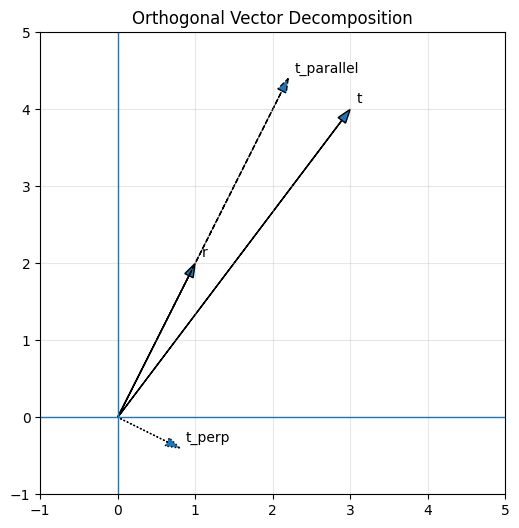

In [56]:
plt.figure(figsize=(6, 6))

def draw_vec(vec, label, linestyle="-"):
    plt.arrow(0, 0, vec[0], vec[1], head_width=0.12, length_includes_head=True, linestyle=linestyle)
    plt.text(vec[0] + 0.08, vec[1] + 0.08, label)

draw_vec(t, "t")
draw_vec(r, "r")
draw_vec(t_parallel, "t_parallel", "--")
draw_vec(t_perpendicular, "t_perp", ":")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.grid(alpha=0.3)
plt.title("Orthogonal Vector Decomposition")
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Vector | Ordered list of numbers. |
| Dimensionality | Jumlah elemen dalam vector secara matematis. |
| Orientation | Bentuk vector sebagai row vector atau column vector. |
| Shape | Cara NumPy menunjukkan struktur array. |
| Vector addition | Penjumlahan element-wise antara dua vector berdimensi sama. |
| Vector subtraction | Pengurangan element-wise antara dua vector berdimensi sama. |
| Scalar multiplication | Perkalian setiap elemen vector dengan scalar. |
| Transpose | Operasi menukar baris dan kolom. |
| Broadcasting | Operasi NumPy untuk memperluas shape array secara otomatis. |
| Norm | Magnitude atau panjang geometris vector. |
| Unit vector | Vector dengan magnitude sama dengan 1. |
| Dot product | Perkalian element-wise lalu dijumlahkan menjadi scalar. |
| Orthogonal vectors | Dua vector dengan dot product nol. |
| Hadamard multiplication | Perkalian element-wise yang menghasilkan vector. |
| Outer product | Perkalian vector yang menghasilkan matrix. |
| Orthogonal decomposition | Pemecahan vector menjadi komponen parallel dan perpendicular. |

## Kesimpulan Chapter

Chapter ini membahas vector sebagai fondasi utama linear algebra. Vector dapat dipahami secara aljabar sebagai daftar angka berurutan, dan secara geometri sebagai garis berarah dengan magnitude dan direction. Pemahaman tentang dimensionality dan orientation sangat penting karena keduanya memengaruhi cara vector diproses dalam NumPy.

Operasi dasar seperti addition, subtraction, scalar multiplication, transpose, dan broadcasting terlihat sederhana, tetapi menjadi dasar untuk operasi linear algebra yang lebih kompleks. Chapter ini juga menunjukkan bahwa ada perbedaan penting antara konsep matematika dan implementasi Python, terutama pada shape, orientation, dan broadcasting.

Dot product menjadi salah satu konsep paling penting dalam chapter ini. Dot product menghasilkan scalar yang dapat ditafsirkan sebagai hubungan antara dua vector. Secara geometri, dot product berkaitan dengan sudut antara vector, dan vector yang orthogonal memiliki dot product sama dengan nol.

Hadamard multiplication dan outer product memperluas cara vector dapat dikalikan. Hadamard multiplication bekerja element-wise dan menghasilkan vector, sedangkan outer product menghasilkan matrix. Di akhir chapter, orthogonal vector decomposition diperkenalkan sebagai proses memecah vector menjadi komponen parallel dan perpendicular terhadap reference vector.

Secara keseluruhan, chapter ini memberikan dasar yang sangat penting untuk memahami chapter selanjutnya. Hampir semua topik linear algebra lanjutan dalam buku ini, seperti matrix multiplication, QR decomposition, least squares, eigendecomposition, dan SVD, dibangun dari konsep-konsep dasar vector yang dibahas pada chapter ini.